In [20]:
!pip install nibabel matplotlib numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### What’s Inside Each BraTS MRI File (`.nii.gz`)

Each file contains **two main components**: **Voxel Data** and **Metadata (Header)**.

#### 1. Voxel Data (Image Content)
- **Type:** 3D NumPy array
- **Shape:** `(240, 240, 155)`
- **Values:** MRI signal intensities representing brain tissue  
  - Brightness varies by modality (T1, T1c, T2, FLAIR)
  - Values are **not standardized** and require normalization

#### 2. Metadata (Header)
- **Affine matrix:** Scanner-recorded voxel → world positioning
- **Voxel spacing:** Physical size of each voxel (scanner resolution, in mm)
- **Dimensions:** Number of voxels along each axis
- **Data type:** How voxel values are stored (e.g., `float32`, `uint8`)

In [22]:
 # CELL 3: Define the loading function
def load_brats_case(case_path):
    """
    Load all BraTS files from a folder.
    
    Parameters:
    -----------
    case_path : str or Path
        Path to the folder containing ONE patient's files
        Example: "data/BraTS-GLI-00005-000"
    
    Returns:
    --------
    dict : Dictionary with all loaded data
    """
    case_path = Path(case_path)
    
    # Check if path exists
    if not case_path.exists():
        raise ValueError(f" Path does not exist: {case_path}")
    
    print(f"📂 Loading case from: {case_path.name}")
    print("=" *360)
    
    modalities = {}
    expected_mods = ['t1n', 't1c', 't2w', 't2f', 'seg']
    
    for mod in expected_mods:
        # Look for files ending with -{modality}.nii.gz
        files = list(case_path.glob(f'*-{mod}.nii*'))        
        if files:
            file_path = files[0]
            print(f"Loading {mod.upper():4s}: {file_path.name}")
            
            # Load the NIFTI file
            nib_img = nib.load(str(file_path))
            
            # Store everything important
            modalities[mod] = {
                'nib_img': nib_img,                      # Original nibabel object
                'data': nib_img.get_fdata(),             # 3D numpy array
                'shape': nib_img.shape,                  # (240, 240, 155)
                'affine': nib_img.affine,                # 4×4 matrix
                'header': nib_img.header,                # Full header
                'voxel_spacing': nib_img.header.get_zooms(),  # (1.0, 1.0, 1.0)
                'dtype': nib_img.get_data_dtype(),       # float32, etc.
            }
        else:
            print(f"Missing {mod.upper():4s}")
    
    print("=" * 60)
    print(f"✓ Loaded {len(modalities)} files successfully!\n")
    
    return modalities

print("Function defined!")
    

Function defined!


### load 1 case

In [ ]:
def inspect_case(data):
    """
    Print detailed information about loaded BraTS case.
    
    This shows you EVERYTHING you need to verify before preprocessing:
    - File shapes
    - Voxel spacing
    - Data types and value ranges
    - Affine matrices
    - Segmentation labels
    
    Parameters:
    -----------
    data : dict
        Output from load_brats_case()
    """
    print("=" * 70)
    print("                   BRATS CASE DETAILED INSPECTION")
    print("=" * 70)
    
    # Get reference values from first available modality
    ref_mod = None
    ref_shape = None
    ref_spacing = None
    ref_affine = None
    
    # Find reference
    for mod_name in ['t1n', 't1c', 't2w', 't2f', 'seg']:
        if mod_name in data:
            ref_mod = mod_name
            ref_shape = data[mod_name]['shape']
            ref_spacing = data[mod_name]['voxel_spacing']
            ref_affine = data[mod_name]['affine']
            break
    
    print(f"\nReference modality: {ref_mod.upper()}")
    print(f"   Reference shape: {ref_shape}")
    print(f"   Reference spacing: {ref_spacing}")
    
    # Inspect each modality
    for mod_name in ['t1n', 't1c', 't2w', 't2f', 'seg']:
        if mod_name not in data:
            continue
            
        info = data[mod_name]
        print(f"\n" + "─" * 70)
        print(f"📁 {mod_name.upper()}")
        print("─" * 70)
        
        # Basic info
        print(f"   Shape:           {info['shape']}")
        print(f"   Voxel spacing:   {info['voxel_spacing'][:3]} mm")
        print(f"   Data type:       {info['dtype']}")
        
        # Value range (different for seg vs modalities)
        if mod_name == 'seg':
            unique_vals = np.unique(info['data'])
            print(f"   Unique labels:   {unique_vals}")
        else:
            print(f"   Value range:     [{info['data'].min():.2f}, {info['data'].max():.2f}]")
            print(f"   Mean intensity:  {info['data'].mean():.2f}")
            print(f"   Std dev:         {info['data'].std():.2f}")
        
        # Check consistency with reference
        print(f"\n   Consistency Checks:")
        
        # Shape check
        if info['shape'] == ref_shape:
            print(f"Shape matches reference")
        else:
            print(f"SHAPE MISMATCH! Expected {ref_shape}, got {info['shape']}")
        
        # Spacing check
        if np.allclose(info['voxel_spacing'][:3], ref_spacing[:3], atol=0.01):
            print(f" Voxel spacing matches reference")
        else:
            print(f"Spacing differs: {info['voxel_spacing'][:3]} vs {ref_spacing[:3]}")
        
        # Affine check
        if np.allclose(info['affine'], ref_affine, atol=1e-3):
            print(f"Affine matrix matches reference")
        else:
            print(f"AFFINE MISMATCH! This will cause alignment issues!")
            print(f"Difference: max={np.abs(info['affine'] - ref_affine).max():.6f}")
    
    # Segmentation-specific checks
    if 'seg' in data:
        print(f"\n" + "=" * 70)
        print(" SEGMENTATION ANALYSIS")
        print("=" * 70)
        
        seg_data = data['seg']['data']
        unique_labels = np.unique(seg_data)
        
        print(f"\n   Unique labels found: {unique_labels}")
        print(f"\n   Expected for BraTS Glioma: [0, 1, 2, 4]")
        print(f"      0 = Background (healthy brain)")
        print(f"      1 = NCR (Necrotic tumor core)")
        print(f"      2 = ED (Peritumoral edema)")
        print(f"      3 = ET (Enhancing tumor)")
        
        # Count voxels per label
        print(f"\n   Voxel counts:")
        total_voxels = seg_data.size
        for label in unique_labels:
            count = np.sum(seg_data == label)
            percentage = (count / total_voxels) * 100
            print(f"      Label {label}: {count:,} voxels ({percentage:.2f}%)")
        
        # Tumor volume estimation
        if data['seg']['voxel_spacing'] is not None:
            voxel_volume = np.prod(data['seg']['voxel_spacing'][:3])  # mm³
            tumor_voxels = np.sum(seg_data > 0)
            tumor_volume_mm3 = tumor_voxels * voxel_volume
            tumor_volume_cm3 = tumor_volume_mm3 / 1000
            print(f"\n   Estimated tumor volume: {tumor_volume_cm3:.2f} cm³")
    

In [26]:
data = load_brats_case("data/raw/BraTS-Africa/95_Glioma/BraTS-SSA-00008-000")
inspect_case(data)

📂 Loading case from: BraTS-SSA-00008-000
Loading T1N : BraTS-SSA-00008-000-t1n.nii
Loading T1C : BraTS-SSA-00008-000-t1c.nii
Loading T2W : BraTS-SSA-00008-000-t2w.nii
Loading T2F : BraTS-SSA-00008-000-t2f.nii
Loading SEG : BraTS-SSA-00008-000-seg.nii
✓ Loaded 5 files successfully!

                   BRATS CASE DETAILED INSPECTION

📌 Reference modality: T1N
   Reference shape: (240, 240, 155)
   Reference spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))

──────────────────────────────────────────────────────────────────────
📁 T1N
──────────────────────────────────────────────────────────────────────
   Shape:           (240, 240, 155)
   Voxel spacing:   (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
   Data type:       float32
   Value range:     [-277.00, 11528.00]
   Mean intensity:  783.09
   Std dev:         1599.08

   Consistency Checks:
      ✓ Shape matches reference
      ✓ Voxel spacing matches reference
      ✓ Affine matrix matches reference

──────────

In [ ]:
def check_consistency(data, verbose=True):
    """
    Verify all modalities are properly aligned and ready for training.
    
    This performs ALL the checks mentioned in the BraTS requirements:
    1. Shape consistency
    2. Affine consistency
    3. Label verification
    
    Parameters:
    -----------
    data : dict
        Output from load_brats_case()
    verbose : bool
        If True, print detailed results
    
    Returns:
    --------
    dict : Results of all checks
    """
    results = {
        'shape_check': False,
        'affine_check': False,
        'labels_check': False,
        'all_passed': False,
        'issues': []
    }
    
    if verbose:
        print("=" * 70)
        print("CONSISTENCY VERIFICATION")
        print("=" * 70)
    
    # Get all available modalities
    mods = [k for k in data.keys()]
    
    if len(mods) < 2:
        results['issues'].append("Need at least 2 modalities to check consistency")
        if verbose:
            print("\n✗ ERROR: Not enough modalities loaded")
        return results
    
    # Reference modality
    ref_name = mods[0]
    ref_shape = data[ref_name]['shape']
    ref_affine = data[ref_name]['affine']
    
    # CHECK 1: Shape Consistency
    if verbose:
        print(f"\nSHAPE CONSISTENCY CHECK")
        print(f"   Reference: {ref_name} with shape {ref_shape}")
        print("   " + "─" * 60)
    
    shape_pass = True
    for mod in mods:
        if data[mod]['shape'] == ref_shape:
            if verbose:
                print(f"   ✓ {mod:4s}: {data[mod]['shape']}")
        else:
            shape_pass = False
            if verbose:
                print(f"   ✗ {mod:4s}: {data[mod]['shape']} ≠ {ref_shape}")
            results['issues'].append(f"{mod} shape mismatch: {data[mod]['shape']} != {ref_shape}")
    
    results['shape_check'] = shape_pass
    if verbose:
        if shape_pass:
            print(f"\n   ✓ All shapes match! Ready to proceed.")
        else:
            print(f"\n   ✗ Shape mismatch detected! Resampling required.")
    
    # CHECK 2: Affine Consistency
    if verbose:
        print(f"\n2️AFFINE MATRIX CONSISTENCY CHECK")
        print("   " + "─" * 60)
    
    affine_pass = True
    for mod in mods:
        if np.allclose(data[mod]['affine'], ref_affine, atol=1e-3):
            if verbose:
                print(f"   ✓ {mod:4s}: Affine matches")
        else:
            affine_pass = False
            max_diff = np.abs(data[mod]['affine'] - ref_affine).max()
            if verbose:
                print(f"   ✗ {mod:4s}: Affine mismatch (max diff: {max_diff:.6f})")
            results['issues'].append(f"{mod} affine mismatch")
    
    results['affine_check'] = affine_pass
    if verbose:
        if affine_pass:
            print(f"\n   ✓ All affines match! Overlays will align correctly.")
        else:
            print(f"\n   ✗ Affine mismatch! Overlays may be misaligned.")
    
    # CHECK 3: Segmentation Labels
    if 'seg' in data:
        if verbose:
            print(f"\nSEGMENTATION LABELS CHECK")
            print("   " + "─" * 60)
        
        labels = np.unique(data['seg']['data'])
        expected_glioma = np.array([0, 1, 2, 4])
        
        if verbose:
            print(f"   Found labels:    {labels}")
            print(f"   Expected (GLI):  {expected_glioma}")
        
        if np.array_equal(labels, expected_glioma):
            results['labels_check'] = True
            if verbose:
                print(f"\n   ✓ Labels match BraTS-GLI standard!")
        else:
            # Check if it's a subset (some labels might be missing)
            if set(labels).issubset(set(expected_glioma)):
                results['labels_check'] = True
                if verbose:
                    print(f"\n   ✓ Labels are valid (subset of expected)")
            else:
                if verbose:
                    print(f"\n   ⚠ Unexpected labels! May be different track (SSA/MEN/PED)")
                    print(f"   → Verify with dataset documentation")
                results['labels_check'] = True  # Not necessarily an error
    
    # OVERALL RESULT
    results['all_passed'] = results['shape_check'] and results['affine_check'] and results['labels_check']
    
    if verbose:
        print("\n" + "=" * 70)
        if results['all_passed']:
            print(" ALL CHECKS PASSED - DATA IS READY!")
        else:
            print(" ISSUES FOUND - SEE ABOVE FOR DETAILS")
        print("=" * 70 + "\n")
    
    return results

# ANALYSIS FUNCTIONS, SMART VISUALIZATION FUNCTION, MULTI-SLICE OVERVIEW

In [ ]:
def analyze_segmentation(data):
    """
    Analyze segmentation to find optimal viewing slices.
    
    Returns:
    --------
    dict : Analysis results including best slices and statistics
    """
    if 'seg' not in data:
        return {'has_seg': False, 'error': 'No segmentation file found'}
    
    seg_data = data['seg']['data']
    shape = seg_data.shape
    
    print("🔍 Analyzing segmentation...")
    print("=" * 70)
    
    # Overall statistics
    unique_labels, counts = np.unique(seg_data, return_counts=True)
    total_voxels = seg_data.size
    
    label_stats = {}
    for label, count in zip(unique_labels, counts):
        label_stats[int(label)] = {
            'count': int(count),
            'percentage': (count / total_voxels) * 100
        }
    
    print(f"📊 Overall Statistics:")
    print(f"   Shape: {shape}")
    print(f"   Total voxels: {total_voxels:,}")
    print(f"\n   Label distribution:")
    
    label_names = {0: 'Background', 1: 'NCR', 2: 'Edema', 4: 'ET'}
    for label in sorted(label_stats.keys()):
        stats = label_stats[label]
        name = label_names.get(label, 'Unknown')
        print(f"      Label {label} ({name:10s}): {stats['count']:8,} voxels ({stats['percentage']:5.2f}%)")
    
    # Analyze each slice
    print(f"\nAnalyzing slices...")
    slice_analysis = []
    
    for z in range(shape[2]):
        slice_data = seg_data[:, :, z]
        tumor_voxels = np.sum(slice_data > 0)
        
        if tumor_voxels > 0:
            # Count each label in this slice
            slice_labels = {}
            for label in unique_labels:
                if label > 0:  # Skip background
                    slice_labels[int(label)] = int(np.sum(slice_data == label))
            
            slice_analysis.append({
                'slice_idx': z,
                'total_tumor': tumor_voxels,
                'labels': slice_labels
            })
    
    if not slice_analysis:
        print("NO TUMOR FOUND in any slice!")
        return {
            'has_seg': True,
            'has_tumor': False,
            'error': 'No tumor voxels found in segmentation'
        }
    
    # Find key slices
    first_slice = slice_analysis[0]['slice_idx']
    last_slice = slice_analysis[-1]['slice_idx']
    
    # Find slice with most tumor
    max_tumor_slice = max(slice_analysis, key=lambda x: x['total_tumor'])
    
    # Find middle slice of tumor region
    middle_slice_idx = slice_analysis[len(slice_analysis) // 2]['slice_idx']
    
    # Select representative slices (spread across tumor region)
    num_slices = len(slice_analysis)
    if num_slices >= 6:
        # Select 6 evenly spaced slices
        indices = [0, num_slices//5, 2*num_slices//5, 3*num_slices//5, 4*num_slices//5, num_slices-1]
        representative_slices = [slice_analysis[i]['slice_idx'] for i in indices]
    else:
        # Use all available slices
        representative_slices = [s['slice_idx'] for s in slice_analysis]
    
    print(f"   Tumor found in {len(slice_analysis)} slices")
    print(f"   First tumor slice:  {first_slice}")
    print(f"   Last tumor slice:   {last_slice}")
    print(f"   Middle slice:       {middle_slice_idx}")
    print(f"   Best slice:         {max_tumor_slice['slice_idx']} ({max_tumor_slice['total_tumor']:,} voxels)")
    
    print(f"\nTop 5 slices by tumor volume:")
    sorted_slices = sorted(slice_analysis, key=lambda x: x['total_tumor'], reverse=True)[:5]
    for i, slice_info in enumerate(sorted_slices, 1):
        print(f"   {i}. Slice {slice_info['slice_idx']:3d}: {slice_info['total_tumor']:5,} voxels")
    
    print("=" * 70)
    
    return {
        'has_seg': True,
        'has_tumor': True,
        'shape': shape,
        'label_stats': label_stats,
        'slice_analysis': slice_analysis,
        'first_slice': first_slice,
        'last_slice': last_slice,
        'middle_slice': middle_slice_idx,
        'best_slice': max_tumor_slice['slice_idx'],
        'best_slice_info': max_tumor_slice,
        'representative_slices': representative_slices,
        'present_labels': list(label_stats.keys())
    }


In [ ]:
def visualize_case_smart(data, slice_idx=None, show_analysis=True):
    """
    Smart visualization that automatically finds and displays optimal slice.
    
    Parameters:
    -----------
    data : dict
        Loaded BraTS case data
    slice_idx : int, optional
        Specific slice to show. If None, automatically finds best slice.
    show_analysis : bool
        If True, print analysis before showing visualization
    """
    
    # Analyze segmentation first
    if show_analysis:
        analysis = analyze_segmentation(data)
    else:
        # Quick analysis without printing
        if 'seg' not in data:
            print("No segmentation found!")
            return
        
        seg_data = data['seg']['data']
        tumor_counts = [np.sum(seg_data[:, :, z] > 0) for z in range(seg_data.shape[2])]
        
        if max(tumor_counts) == 0:
            print("No tumor found in segmentation!")
            return
        
        analysis = {
            'has_tumor': True,
            'best_slice': np.argmax(tumor_counts)
        }
    
    if not analysis.get('has_tumor', False):
        print("Cannot visualize: No tumor found")
        return
    
    # Determine which slice to show
    if slice_idx is None:
        slice_idx = analysis['best_slice']
        print(f"\n Auto-selected optimal slice: {slice_idx}")
    else:
        print(f"\n Using specified slice: {slice_idx}")
    
    seg_data = data['seg']['data']
    seg_slice = seg_data[:, :, slice_idx]
    tumor_count = np.sum(seg_slice > 0)
    
    if tumor_count == 0:
        print(f"\nWARNING: Slice {slice_idx} has NO tumor!")
        if 'first_slice' in analysis and 'last_slice' in analysis:
            print(f"   Tumor exists in slices {analysis['first_slice']}-{analysis['last_slice']}")
            print(f"   Recommended: Try slice {analysis['best_slice']} (best slice)")
        return
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'BraTS Case Visualization - Slice {slice_idx} ({tumor_count} tumor voxels)', 
                 fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()
    
    # Plot each modality with overlay
    mod_names = ['t1n', 't1c', 't2w', 't2f']
    
    for i, mod in enumerate(mod_names):
        if mod in data:
            img_slice = data[mod]['data'][:, :, slice_idx]
            
            # Adaptive contrast adjustment
            nonzero_vals = img_slice[img_slice > 0]
            if len(nonzero_vals) > 0:
                vmin = 0
                vmax = np.percentile(nonzero_vals, 99)
            else:
                vmin, vmax = img_slice.min(), img_slice.max()
            
            # Display MRI
            axes[i].imshow(img_slice.T, cmap='gray', origin='lower', 
                          vmin=vmin, vmax=vmax)
            axes[i].set_title(f'{mod.upper()}', fontsize=14, fontweight='bold')
            axes[i].axis('off')
            
            # Overlay tumor with transparency
            tumor_mask = np.ma.masked_where(seg_slice == 0, seg_slice)
            axes[i].imshow(tumor_mask.T, cmap='hot', alpha=0.5, 
                          origin='lower', vmin=0, vmax=4)
            
            # Add explanation text for key modalities
            if mod == 't1c':
                axes[i].text(0.02, 0.98, 'Best for tumor', 
                           transform=axes[i].transAxes,
                           fontsize=9, va='top', 
                           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
            elif mod == 't2f':
                axes[i].text(0.02, 0.98, 'Best for edema', 
                           transform=axes[i].transAxes,
                           fontsize=9, va='top',
                           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        else:
            axes[i].text(0.5, 0.5, f'{mod.upper()}\nNot Available', 
                        ha='center', va='center', fontsize=14,
                        transform=axes[i].transAxes,
                        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
            axes[i].axis('off')
    
    # Segmentation panel with smart colormap
    present_labels = np.unique(seg_slice)
    present_labels = present_labels[present_labels > 0]  # Exclude background
    
    # Create custom colormap based on present labels
    if len(present_labels) > 0:
        # Define colors for each possible label
        label_colors = {0: 'black', 1: 'blue', 2: 'green', 3: 'red'}
        
        # Build colormap for present labels
        colors = ['black']  # Background
        boundaries = [0, 0.5]
        
        for label in [1, 2, 4]:
            if label in present_labels:
                colors.append(label_colors[label])
                boundaries.append(label + 0.5)
        
        cmap = ListedColormap(colors)
        norm = BoundaryNorm(boundaries, cmap.N)
        
        im = axes[4].imshow(seg_slice.T, cmap=cmap, norm=norm, 
                           origin='lower', interpolation='nearest')
        axes[4].set_title('Segmentation Labels', fontsize=14, fontweight='bold')
        axes[4].axis('off')
        
        # Colorbar
        cbar = plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
        cbar.set_label('Label', rotation=270, labelpad=15)
    else:
        axes[4].text(0.5, 0.5, 'No tumor\nin this slice', 
                    ha='center', va='center', fontsize=14,
                    transform=axes[4].transAxes)
        axes[4].axis('off')
    
    # Information panel
    axes[5].text(0.05, 0.95, 'Slice Information', 
                fontsize=13, fontweight='bold', va='top')
    
    y_pos = 0.85
    
    # Slice statistics
    axes[5].text(0.05, y_pos, f'Slice Index: {slice_idx}', 
                fontsize=10, family='monospace', va='top')
    y_pos -= 0.08
    
    axes[5].text(0.05, y_pos, f'Total voxels: {seg_slice.size:,}', 
                fontsize=10, family='monospace', va='top')
    y_pos -= 0.08
    
    axes[5].text(0.05, y_pos, f'Tumor voxels: {tumor_count:,}', 
                fontsize=10, family='monospace', va='top', color='red')
    y_pos -= 0.12
    
    # Label breakdown
    axes[5].text(0.05, y_pos, 'Labels Present:', 
                fontsize=11, fontweight='bold', va='top')
    y_pos -= 0.08
    
    label_names = {0: 'Background', 1: 'NCR', 2: 'Edema', 3: 'ET'}
    label_colors_text = {0: 'black', 1: 'blue', 2: 'green', 3: 'red'}
    
    for label in sorted(np.unique(seg_slice)):
        count = np.sum(seg_slice == label)
        percentage = (count / seg_slice.size) * 100
        name = label_names.get(label, 'Unknown')
        color = label_colors_text.get(label, 'black')
        
        if label == 0:
            axes[5].text(0.05, y_pos, f'  {int(label)}: {name} ({percentage:.1f}%)', 
                        fontsize=9, family='monospace', va='top', color='gray')
        else:
            axes[5].text(0.05, y_pos, f'  {int(label)}: {name} ({count:,} voxels)', 
                        fontsize=9, family='monospace', va='top', color=color, 
                        fontweight='bold')
        y_pos -= 0.07
    
    # Recommendations
    if 'representative_slices' in analysis:
        y_pos -= 0.05
        axes[5].text(0.05, y_pos, 'Other Good Slices:', 
                    fontsize=11, fontweight='bold', va='top')
        y_pos -= 0.08
        
        other_slices = [s for s in analysis['representative_slices'][:4] if s != slice_idx]
        for s in other_slices[:3]:
            axes[5].text(0.05, y_pos, f'  • Slice {s}', 
                        fontsize=9, family='monospace', va='top')
            y_pos -= 0.06
    
    axes[5].set_xlim(0, 1)
    axes[5].set_ylim(0, 1)
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print explanation
    print(f"\n Explanation:")
    print(f"   • Showing slice {slice_idx} out of {seg_data.shape[2]} total slices")
    print(f"   • This slice contains {tumor_count:,} tumor voxels ({(tumor_count/seg_slice.size)*100:.2f}%)")
    print(f"   • Red overlay = tumor regions")
    print(f"   • T1c shows tumor brightest (contrast enhancement)")
    if 't2f' in data:
        print(f"   • T2f shows edema brightest (fluid signal)")

In [ ]:
def visualize_tumor_progression(data, num_slices=6):
    """
    Show tumor progression across multiple slices.
    
    Parameters:
    -----------
    data : dict
        Loaded BraTS case data
    num_slices : int
        Number of slices to show (default: 6)
    """
    analysis = analyze_segmentation(data)
    
    if not analysis.get('has_tumor', False):
        print("Cannot visualize: No tumor found")
        return
    
    # Get representative slices
    slices_to_show = analysis['representative_slices'][:num_slices]
    
    # Determine grid size
    if num_slices <= 3:
        nrows, ncols = 1, num_slices
        figsize = (6*num_slices, 6)
    else:
        nrows = 2
        ncols = (num_slices + 1) // 2
        figsize = (6*ncols, 12)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.suptitle('Tumor Progression Across Slices', fontsize=16, fontweight='bold')
    
    if num_slices == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    seg_data = data['seg']['data']
    
    for i, slice_idx in enumerate(slices_to_show):
        if i >= len(axes):
            break
        
        # Get T1c for background (best for visualization)
        if 't1c' in data:
            img_slice = data['t1c']['data'][:, :, slice_idx]
            nonzero = img_slice[img_slice > 0]
            if len(nonzero) > 0:
                vmax = np.percentile(nonzero, 99)
            else:
                vmax = img_slice.max()
            axes[i].imshow(img_slice.T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
        
        # Overlay tumor
        seg_slice = seg_data[:, :, slice_idx]
        tumor_mask = np.ma.masked_where(seg_slice == 0, seg_slice)
        axes[i].imshow(tumor_mask.T, cmap='hot', alpha=0.6, origin='lower', vmin=0, vmax=4)
        
        tumor_count = np.sum(seg_slice > 0)
        axes[i].set_title(f'Slice {slice_idx}\n({tumor_count:,} tumor voxels)', 
                         fontsize=12, fontweight='bold')
        axes[i].axis('off')
        
        # Mark if this is the best slice
        if slice_idx == analysis['best_slice']:
            axes[i].text(0.5, 0.02, 'BEST SLICE', 
                        transform=axes[i].transAxes,
                        ha='center', fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
    
    # Hide extra subplots
    for i in range(len(slices_to_show), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTumor Progression:")
    print(f"   • Showing {len(slices_to_show)} representative slices")
    print(f"   • Tumor spans slices {analysis['first_slice']}-{analysis['last_slice']}")
    print(f"   • Total {len(analysis['slice_analysis'])} slices contain tumor")



In [ ]:
def show_case(data, slice_idx=None, show_progression=False):
    """
    Convenient all-in-one visualization function.
    
    Parameters:
    -----------
    data : dict
        Loaded BraTS case data
    slice_idx : int, optional
        Specific slice to show (None = auto-select best)
    show_progression : bool
        If True, also show multi-slice progression view
    
    Examples:
    ---------
    >>> # Auto-select best slice
    >>> show_case(data)
    
    >>> # Show specific slice
    >>> show_case(data, slice_idx=124)
    
    >>> # Show best slice + progression
    >>> show_case(data, show_progression=True)
    """
    print("BRATS CASE VISUALIZATION")
    
    # Main visualization
    visualize_case_smart(data, slice_idx=slice_idx, show_analysis=True)
    
    # Optional progression view
    if show_progression:
        print("\n" + "-" * 70)
        visualize_tumor_progression(data, num_slices=6)

In [ ]:
# 3-View Visualization (Axial, Sagittal, Coronal)

def visualize_three_views(data, modality='t1c'):
    """
    Show the same point in 3 different views (medical standard).
    
    Parameters:
    -----------
    data : dict
        Output from load_brats_case()
    modality : str
        Which modality to display
    """
    if modality not in data:
        print(f"Error: {modality} not found!")
        return
    
    vol = data[modality]['data']
    
    # Find center of tumor if seg available
    if 'seg' in data:
        seg = data['seg']['data']
        tumor_coords = np.where(seg > 0)
        if len(tumor_coords[0]) > 0:
            x = int(np.mean(tumor_coords[0]))
            y = int(np.mean(tumor_coords[1]))
            z = int(np.mean(tumor_coords[2]))
        else:
            x, y, z = [s//2 for s in vol.shape]
    else:
        x, y, z = [s//2 for s in vol.shape]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{modality.upper()} - Three Anatomical Views', fontsize=14, fontweight='bold')
    
    # Axial (horizontal slice - looking from top down)
    axes[0].imshow(vol[:, :, z].T, cmap='gray', origin='lower')
    axes[0].axhline(y, color='red', linewidth=0.5, linestyle='--')
    axes[0].axvline(x, color='red', linewidth=0.5, linestyle='--')
    axes[0].set_title(f'Axial View (Z={z})\n(Top-down)', fontsize=12)
    axes[0].axis('off')
    
    # Sagittal (side view)
    axes[1].imshow(vol[x, :, :].T, cmap='gray', origin='lower')
    axes[1].axhline(z, color='red', linewidth=0.5, linestyle='--')
    axes[1].axvline(y, color='red', linewidth=0.5, linestyle='--')
    axes[1].set_title(f'Sagittal View (X={x})\n(Side)', fontsize=12)
    axes[1].axis('off')
    
    # Coronal (front view)
    axes[2].imshow(vol[:, y, :].T, cmap='gray', origin='lower')
    axes[2].axhline(z, color='red', linewidth=0.5, linestyle='--')
    axes[2].axvline(x, color='red', linewidth=0.5, linestyle='--')
    axes[2].set_title(f'Coronal View (Y={y})\n(Front)', fontsize=12)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()



🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠
           BRATS CASE VISUALIZATION
🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

🔍 Analyzing segmentation...
📊 Overall Statistics:
   Shape: (240, 240, 155)
   Total voxels: 8,928,000

   Label distribution:
      Label 0 (Background): 8,870,695 voxels (99.36%)
      Label 1 (NCR       ):   11,738 voxels ( 0.13%)
      Label 2 (Edema     ):   12,836 voxels ( 0.14%)
      Label 3 (Unknown   ):   32,731 voxels ( 0.37%)

🔬 Analyzing slices...
   ✅ Tumor found in 47 slices
   First tumor slice:  49
   Last tumor slice:   95
   Middle slice:       72
   Best slice:         74 (1,978 voxels)

🔝 Top 5 slices by tumor volume:
   1. Slice  74: 1,978 voxels
   2. Slice  75: 1,966 voxels
   3. Slice  72: 1,965 voxels
   4. Slice  73: 1,958 voxels
   5. Slice  71: 1,957 voxels

✨ Auto-selected optimal slice: 74


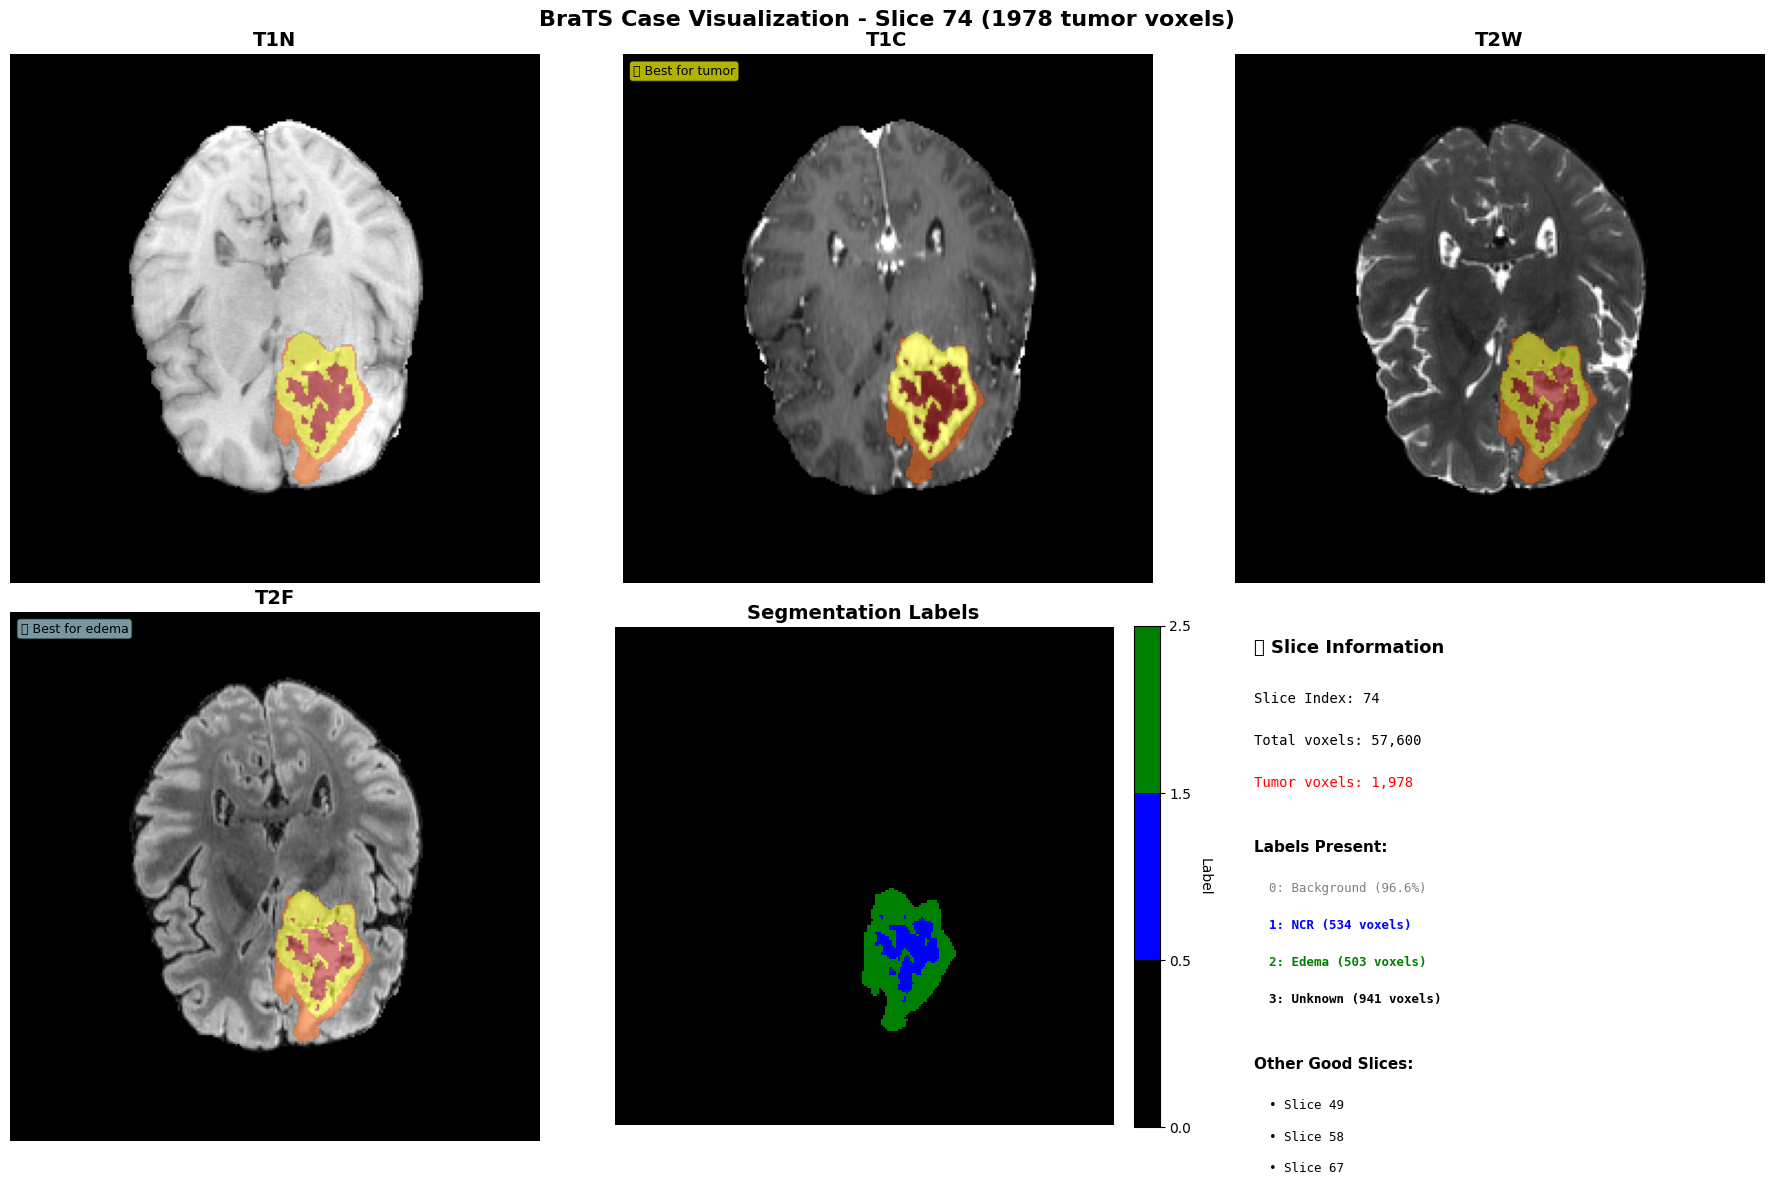


📖 Explanation:
   • Showing slice 74 out of 155 total slices
   • This slice contains 1,978 tumor voxels (3.43%)
   • Red overlay = tumor regions
   • T1c shows tumor brightest (contrast enhancement)
   • T2f shows edema brightest (fluid signal)

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠
           BRATS CASE VISUALIZATION
🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

🔍 Analyzing segmentation...
📊 Overall Statistics:
   Shape: (240, 240, 155)
   Total voxels: 8,928,000

   Label distribution:
      Label 0 (Background): 8,870,695 voxels (99.36%)
      Label 1 (NCR       ):   11,738 voxels ( 0.13%)
      Label 2 (Edema     ):   12,836 voxels ( 0.14%)
      Label 3 (Unknown   ):   32,731 voxels ( 0.37%)

🔬 Analyzing slices...
   ✅ Tumor found in 47 slices
   First tumor slice:  49
   Last tumor slice:   95
   Middle slice:       72
   Best slice:         74 (1,978 voxels)

🔝 Top 5 slices by tumor volume:
   1. Slice  74: 1,978 voxels
   2. Slice  75: 1,966 voxels
   3. Slice  72: 1,965 voxels
   4. Sl

In [19]:
# Method 1: Simplest - auto-select best slice
#show_case(data)
# Method 2: Show specific slice
#show_case(data, slice_idx=124)
# Method 3: Show best slice + tumor progression
# show_case(data, show_progression=True)


# # Method 4: Just the smart visualization
#visualize_case_smart(data)
# Method 5: Just the analysis
#analysis = analyze_segmentation(data)
# Method 6: Just the progression view
#visualize_tumor_progression(data)

#if 't2f' in data:
            #visualize_three_views(data, 't2f')
# visualize_three_views(data, modality='t1c', point=(120, 100, 75))

### Double check / FIX


In [46]:
def check_all_shapes(data_dir):
    shapes = {}
    for case_folder in Path(data_dir).glob('BraTS-*'):
        try:
            data = load_brats_case(case_folder)
            shape = data['t1c']['shape']
            if shape not in shapes:
                shapes[shape] = []
            shapes[shape].append(case_folder.name)
        except Exception as e:
            print(f"Error loading {case_folder.name}: {e}")
    
    print("\nShape Distribution:")
    for shape, cases in shapes.items():
        print(f"{shape}: {len(cases)} cases")
    
    return shapes


'''
#TODO: Check other cases
cases = ['BraTS-GLI-00005-100', 'BraTS-GLI-00006-100', ...]
for case in cases:
    data = load_brats_case(case)
    print(f"{case}: {data['t1c']['shape']}")
'''

'\n#TODO: Check other cases\ncases = [\'BraTS-GLI-00005-100\', \'BraTS-GLI-00006-100\', ...]\nfor case in cases:\n    data = load_brats_case(case)\n    print(f"{case}: {data[\'t1c\'][\'shape\']}")\n'

In [ ]:
shape_2023 = check_all_shapes("data/raw/BraTS24/BraTS-GLI/training_data")
#shape_africa = check_all_shapes("data/raw/BraTS-Africa/95_Glioma")

📂 Loading case from: BraTS-GLI-02314-100
Loading T1N : BraTS-GLI-02314-100-t1n.nii.gz
Loading T1C : BraTS-GLI-02314-100-t1c.nii.gz
Loading T2W : BraTS-GLI-02314-100-t2w.nii.gz
Loading T2F : BraTS-GLI-02314-100-t2f.nii.gz
Loading SEG : BraTS-GLI-02314-100-seg.nii.gz
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-GLI-02181-102
Loading T1N : BraTS-GLI-02181-102-t1n.nii.gz
Loading T1C : BraTS-GLI-02181-102-t1c.nii.gz
Loading T2W : BraTS-GLI-02181-102-t2w.nii.gz
Loading T2F : BraTS-GLI-02181-102-t2f.nii.gz
Loading SEG : BraTS-GLI-02181-102-seg.nii.gz
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-GLI-00517-100
Loading T1N : BraTS-GLI-00517-100-t1n.nii.gz
Loading T1C : BraTS-GLI-00517-100-t1c.nii.gz
Loading T2W : BraTS-GLI-00517-100-t2w.nii.gz
Loading T2F : BraTS-GLI-00517-100-t2f.nii.gz
Loading SEG : BraTS-GLI-00517-100-seg.nii.gz
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-GLI-02300-100
Loading T1N : BraTS-GLI-02300-100-t1n.nii.gz
Loading T1C : BraTS-

In [ ]:
def count_missing_labels(data_dir):
    """
    Count label distribution across all cases in a directory.
    Handles cases with missing segmentation gracefully.
    """
    label_stats = {
        'total_cases': 0,
        'cases_with_seg': 0,
        'cases_without_seg': 0,
        'has_all_labels': 0,
        'missing_1': 0,
        'missing_2': 0,
        'missing_3': 0,
        'label_distributions': []  # Store each case's labels
    }
    
    print(f"Scanning: {data_dir}")
    print("=" * 70)
    
    for case_folder in Path(data_dir).glob('BraTS-*'):
        label_stats['total_cases'] += 1
        
        try:
            data = load_brats_case(case_folder)
            
            # Check if segmentation exists
            if 'seg' not in data:
                label_stats['cases_without_seg'] += 1
                print(f"⚠️  {case_folder.name}: No segmentation file")
                continue
            
            label_stats['cases_with_seg'] += 1
            
            # Get unique labels
            labels = np.unique(data['seg']['data'])
            label_set = set(labels)
            
            # Store for analysis
            label_stats['label_distributions'].append({
                'case': case_folder.name,
                'labels': list(labels)
            })
            
            # Check completeness
            if set([0, 1, 2, 3]).issubset(label_set):
                label_stats['has_all_labels'] += 1
                print(f"✓ {case_folder.name}: All labels [0,1,2,4]")
            else:
                # Count which labels are missing
                missing = []
                if 1 not in label_set:
                    label_stats['missing_1'] += 1
                    missing.append('1')
                if 2 not in label_set:
                    label_stats['missing_2'] += 1
                    missing.append('2')
                if 4 not in label_set:
                    label_stats['missing_4'] += 1
                    missing.append('4')
                
                print(f"{case_folder.name}: Missing labels {missing}, has {list(labels)}")
        
        except Exception as e:
            print(f{case_folder.name}: Error - {e}")
            label_stats['cases_without_seg'] += 1
    
    # Print summary
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print(f"Total cases scanned:        {label_stats['total_cases']}")
    print(f"Cases with segmentation:    {label_stats['cases_with_seg']}")
    print(f"Cases without segmentation: {label_stats['cases_without_seg']}")
    
    if label_stats['cases_with_seg'] > 0:
        print(f"\nOf cases with segmentation:")
        print(f"  Has all labels [0,1,2,3]: {label_stats['has_all_labels']} ({100*label_stats['has_all_labels']/label_stats['cases_with_seg']:.1f}%)")
        print(f"  Missing label 1 (NCR):    {label_stats['missing_1']} ({100*label_stats['missing_1']/label_stats['cases_with_seg']:.1f}%)")
        print(f"  Missing label 2 (ED):     {label_stats['missing_2']} ({100*label_stats['missing_2']/label_stats['cases_with_seg']:.1f}%)")
        print(f"  Missing label 3 (ET):     {label_stats['missing_4']} ({100*label_stats['missing_4']/label_stats['cases_with_seg']:.1f}%)")
    
    return label_stats

In [36]:
stats_2024 = count_missing_labels("data/raw/BraTS24/BraTS-GLI/training_data")
#stats_2024 = count_missing_labels("data/raw/BraTS-Africa/95_Glioma")


Scanning: data/raw/BraTS24/BraTS-GLI/training_data
📂 Loading case from: BraTS-GLI-02314-100
Loading T1N : BraTS-GLI-02314-100-t1n.nii.gz
Loading T1C : BraTS-GLI-02314-100-t1c.nii.gz
Loading T2W : BraTS-GLI-02314-100-t2w.nii.gz
Loading T2F : BraTS-GLI-02314-100-t2f.nii.gz
Loading SEG : BraTS-GLI-02314-100-seg.nii.gz
✓ Loaded 5 files successfully!

⚠️  BraTS-GLI-02314-100: Missing labels ['1'], has [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
📂 Loading case from: BraTS-GLI-02181-102
Loading T1N : BraTS-GLI-02181-102-t1n.nii.gz
Loading T1C : BraTS-GLI-02181-102-t1c.nii.gz
Loading T2W : BraTS-GLI-02181-102-t2w.nii.gz
Loading T2F : BraTS-GLI-02181-102-t2f.nii.gz
Loading SEG : BraTS-GLI-02181-102-seg.nii.gz
✓ Loaded 5 files successfully!

⚠️  BraTS-GLI-02181-102: Missing labels ['1'], has [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
📂 Loading case from: BraTS-GLI-00517-100
Loading T1N : BraTS-GLI-00517-100-t1n.nii.gz
Loading T1C : BraTS-GLI-005

In [ ]:
def investigate_africa_labels(data_dir):
    """
    Deep dive into what labels actually exist in Africa dataset.
    """
    print("Investigating Africa Label Distribution...")
    print("=" * 70)
    
    all_unique_labels = set()
    label_examples = []
    
    for case_folder in Path(data_dir).glob('BraTS-*'):
        try:
            data = load_brats_case(case_folder)
            
            if 'seg' not in data:
                continue
            
            labels = np.unique(data['seg']['data'])
            all_unique_labels.update(labels)
            
            # Store first 5 examples
            if len(label_examples) < 5:
                label_examples.append({
                    'case': case_folder.name,
                    'labels': list(labels),
                    'counts': {int(l): int(np.sum(data['seg']['data'] == l)) 
                              for l in labels}
                })
        
        except Exception as e:
            print(f"Error: {case_folder.name} - {e}")
    
    print("\nFINDINGS:")
    print(f"All unique labels across dataset: {sorted(all_unique_labels)}")
    
    print("\nExample Cases:")
    for example in label_examples:
        print(f"\n{example['case']}:")
        print(f"  Labels: {example['labels']}")
        print(f"  Counts:")
        for label, count in example['counts'].items():
            print(f"    {label}: {count:,} voxels")
    
    return all_unique_labels, label_examples


In [32]:
unique_labels, examples = investigate_africa_labels("data/raw/BraTS-Africa/95_Glioma")

Investigating Africa Label Distribution...
📂 Loading case from: BraTS-SSA-00158-000
Loading T1N : BraTS-SSA-00158-000-t1n.nii
Loading T1C : BraTS-SSA-00158-000-t1c.nii
Loading T2W : BraTS-SSA-00158-000-t2w.nii
Loading T2F : BraTS-SSA-00158-000-t2f.nii
Loading SEG : BraTS-SSA-00158-000-seg.nii
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-SSA-00206-000
Loading T1N : BraTS-SSA-00206-000-t1n.nii
Loading T1C : BraTS-SSA-00206-000-t1c.nii
Loading T2W : BraTS-SSA-00206-000-t2w.nii
Loading T2F : BraTS-SSA-00206-000-t2f.nii
Loading SEG : BraTS-SSA-00206-000-seg.nii
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-SSA-00010-000
Loading T1N : BraTS-SSA-00010-000-t1n.nii
Loading T1C : BraTS-SSA-00010-000-t1c.nii
Loading T2W : BraTS-SSA-00010-000-t2w.nii
Loading T2F : BraTS-SSA-00010-000-t2f.nii
Loading SEG : BraTS-SSA-00010-000-seg.nii
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-SSA-00011-000
Loading T1N : BraTS-SSA-00011-000-t1n.nii
Loading T1C : BraTS-SSA-0

In [ ]:
def analyze_missing_et(data_dir):
    """
    Analyze cases missing enhancing tumor.
    """
    missing_et_cases = []
    failed_cases = []
    
    for case_folder in Path(data_dir).glob('BraTS-*'):
        try:
            data = load_brats_case(case_folder)
            
            if 'seg' not in data:
                continue
            
            labels = np.unique(data['seg']['data'])
            
            if 4 not in labels:
                # This case is missing ET
                missing_et_cases.append({
                    'case': case_folder.name,
                    'labels': list(labels),
                    'has_ncr': 1 in labels,
                    'has_ed': 2 in labels
                })
        except Exception as e:
            print(f"Failed to load {case_folder.name}: {e}")
            failed_cases.append({
                'case': case_folder.name,
                'error': str(e)
            })
            continue
    
    print(f"Found {len(missing_et_cases)} cases missing ET")
    print(f"Failed to load {len(failed_cases)} cases")
    
    # Analyze patterns
    only_ed = sum(1 for c in missing_et_cases if c['labels'] == [0, 2])
    ed_and_ncr = sum(1 for c in missing_et_cases if set([0,1,2]).issubset(c['labels']))
    
    print(f"\nBreakdown:")
    print(f"  Only Edema (0,2):         {only_ed}")
    print(f"  Edema + NCR (0,1,2):      {ed_and_ncr}")
    
    return missing_et_cases, failed_cases


In [44]:
missing_et = analyze_missing_et("data/raw/BraTS24/BraTS-GLI/training_data")
#missing_et = analyze_missing_et("data/raw/BraTS-Africa/95_Glioma")

📂 Loading case from: BraTS-GLI-02314-100
Loading T1N : BraTS-GLI-02314-100-t1n.nii.gz
Loading T1C : BraTS-GLI-02314-100-t1c.nii.gz
Loading T2W : BraTS-GLI-02314-100-t2w.nii.gz
Loading T2F : BraTS-GLI-02314-100-t2f.nii.gz
Loading SEG : BraTS-GLI-02314-100-seg.nii.gz
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-GLI-02181-102
Loading T1N : BraTS-GLI-02181-102-t1n.nii.gz
Loading T1C : BraTS-GLI-02181-102-t1c.nii.gz
Loading T2W : BraTS-GLI-02181-102-t2w.nii.gz
Loading T2F : BraTS-GLI-02181-102-t2f.nii.gz
Loading SEG : BraTS-GLI-02181-102-seg.nii.gz
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-GLI-00517-100
Loading T1N : BraTS-GLI-00517-100-t1n.nii.gz
Loading T1C : BraTS-GLI-00517-100-t1c.nii.gz
Loading T2W : BraTS-GLI-00517-100-t2w.nii.gz
Loading T2F : BraTS-GLI-00517-100-t2f.nii.gz
Loading SEG : BraTS-GLI-00517-100-seg.nii.gz
✓ Loaded 5 files successfully!

📂 Loading case from: BraTS-GLI-02300-100
Loading T1N : BraTS-GLI-02300-100-t1n.nii.gz
Loading T1C : BraTS-

In [ ]:
# TODO: Print voxel spacing
data = load_brats_case("data/raw/BraTS24/BraTS-GLI/training_data/BraTS-GLI-00046-100")

print("Voxel Spacing Check:")
for mod in ['t1n', 't1c', 't2w', 't2f', 'seg']:
    if mod in data:
        spacing = data[mod]['voxel_spacing'][:3]
        print(f"{mod}: {spacing}")

'''
missing_et = analyze_missing_et("data/raw/BraTS24/BraTS-GLI/training_data")
#missing_et = analyze_missing_et("data/raw/BraTS-Africa/95_Glioma")
Questions:
Is spacing truly isotropic (1mm³)?
pythonExpected: (1.0, 1.0, 1.0) mm
Your data: ???
Is spacing consistent across all modalities?

All should have identical spacing
If not → preprocessing problem

Action item:
Run the spacing check and report findings.
'''

📂 Loading case from: BraTS-GLI-00046-100
Loading T1N : BraTS-GLI-00046-100-t1n.nii.gz
Loading T1C : BraTS-GLI-00046-100-t1c.nii.gz
Loading T2W : BraTS-GLI-00046-100-t2w.nii.gz
Loading T2F : BraTS-GLI-00046-100-t2f.nii.gz
Loading SEG : BraTS-GLI-00046-100-seg.nii.gz
✓ Loaded 5 files successfully!

Voxel Spacing Check:
t1n: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
t1c: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
t2w: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
t2f: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
seg: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


'\nmissing_et = analyze_missing_et("data/raw/BraTS24/BraTS-GLI/training_data")\n#missing_et = analyze_missing_et("data/raw/BraTS-Africa/95_Glioma")\nQuestions:\n❓ Is spacing truly isotropic (1mm³)?\npythonExpected: (1.0, 1.0, 1.0) mm\nYour data: ???\n❓ Is spacing consistent across all modalities?\n\nAll should have identical spacing\nIf not → preprocessing problem\n\nAction item:\nRun the spacing check and report findings.\n'

In [ ]:
# Affine Matrix Consistency 

data = load_brats_case("data/raw/BraTS24/BraTS-GLI/training_data/BraTS-GLI-02062-100")

print("Affine Matrix Check:")
print("\nT1c affine:")
print(data['t1c']['affine'])

print("\nSeg affine:")
print(data['seg']['affine'])

print("\nDifference:")
print(np.abs(data['t1c']['affine'] - data['seg']['affine']))

print("\nMax difference:")
print(np.abs(data['t1c']['affine'] - data['seg']['affine']).max())

'''
Questions:
What is the actual numerical difference?

< 0.001 mm → Good
0.001 - 0.1 mm → Acceptable


0.1 mm → Problem!



Do the visualizations look aligned?

Did tumor overlay sit on bright regions in T1c? 
Any "floating" masks? 
'''

📂 Loading case from: BraTS-SSA-00068-000
Loading T1N : BraTS-SSA-00068-000-t1n.nii
Loading T1C : BraTS-SSA-00068-000-t1c.nii
Loading T2W : BraTS-SSA-00068-000-t2w.nii
Loading T2F : BraTS-SSA-00068-000-t2f.nii
Loading SEG : BraTS-SSA-00068-000-seg.nii
✓ Loaded 5 files successfully!

Affine Matrix Check:

T1c affine:
[[  1.   0.  -0.  -0.]
 [  0.   1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Seg affine:
[[  1.   0.   0.   0.]
 [  0.   1.   0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Difference:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Max difference:
0.0


'\nQuestions:\n❓ What is the actual numerical difference?\n\n< 0.001 mm → Good\n0.001 - 0.1 mm → Acceptable\n\n\n0.1 mm → Problem!\n\n\n\n❓ Do the visualizations look aligned?\n\nDid tumor overlay sit on bright regions in T1c? ✅\nAny "floating" masks? ❌\n'

In [ ]:
'''
 Tumor Volume Sanity Check 🔍
What we can calculate but haven't yet:
5. Tumor Volume Sanity Check 🔍
What we can calculate but haven't yet:
python# TODO: Calculate actual tumor volume
'''
data = load_brats_case("data/raw/BraTS24/BraTS-GLI/training_data/BraTS-GLI-02062-100")

seg_data = data['seg']['data']
voxel_spacing = data['seg']['voxel_spacing'][:3]

# Voxel volume
voxel_volume = np.prod(voxel_spacing)  # mm³

# Count each label
ncr_voxels = np.sum(seg_data == 1)
ed_voxels = np.sum(seg_data == 2)
et_voxels = np.sum(seg_data == 4)
total_tumor = ncr_voxels + ed_voxels + et_voxels

# Calculate volumes
ncr_volume = ncr_voxels * voxel_volume / 1000  # cm³
ed_volume = ed_voxels * voxel_volume / 1000
et_volume = et_voxels * voxel_volume / 1000
total_volume = total_tumor * voxel_volume / 1000

print(f"Tumor Volumes:")
print(f"  NCR:   {ncr_volume:.2f} cm³")
print(f"  Edema: {ed_volume:.2f} cm³")
print(f"  ET:    {et_volume:.2f} cm³")
print(f"  Total: {total_volume:.2f} cm³")


📂 Loading case from: BraTS-SSA-00008-000
Loading T1N : BraTS-SSA-00008-000-t1n.nii
Loading T1C : BraTS-SSA-00008-000-t1c.nii
Loading T2W : BraTS-SSA-00008-000-t2w.nii
Loading T2F : BraTS-SSA-00008-000-t2f.nii
Loading SEG : BraTS-SSA-00008-000-seg.nii
✓ Loaded 5 files successfully!

Tumor Volumes:
  NCR:   19.33 cm³
  Edema: 47.94 cm³
  ET:    0.00 cm³
  Total: 67.28 cm³


In [68]:
#data = load_brats_case("data/raw/BraTS-Africa/95_Glioma/BraTS-SSA-00008-000")
data = load_brats_case("data/raw/BraTS24/BraTS-GLI/training_data/BraTS-GLI-02062-100")

print("\n5. TUMOR VOLUMES:")
seg = data['seg']['data']
voxel_vol = np.prod(data['seg']['voxel_spacing'][:3])
for label in [1, 2, 4]:
    count = np.sum(seg == label)
    volume = count * voxel_vol / 1000
    print(f"   Label {label}: {count:,} voxels = {volume:.2f} cm³")
    
    # 7. Intensity ranges
print("\n6. INTENSITY RANGES:")
for mod in ['t1n', 't1c', 't2w', 't2f']:
    if mod in data:
        nonzero = data[mod]['data'][data[mod]['data'] > 0]
        print(f"   {mod}: [{nonzero.min():.1f}, {nonzero.max():.1f}], mean={nonzero.mean():.1f}")
    
print("\n" + "="*70)

📂 Loading case from: BraTS-GLI-02062-100
Loading T1N : BraTS-GLI-02062-100-t1n.nii.gz
Loading T1C : BraTS-GLI-02062-100-t1c.nii.gz
Loading T2W : BraTS-GLI-02062-100-t2w.nii.gz
Loading T2F : BraTS-GLI-02062-100-t2f.nii.gz
Loading SEG : BraTS-GLI-02062-100-seg.nii.gz
✓ Loaded 5 files successfully!


5. TUMOR VOLUMES:
   Label 1: 0 voxels = 0.00 cm³
   Label 2: 26,522 voxels = 26.52 cm³
   Label 4: 2,785 voxels = 2.79 cm³

6. INTENSITY RANGES:
   t1n: [2.9, 1453.5], mean=351.0
   t1c: [6.0, 1849.5], mean=385.9
   t2w: [0.0, 1569.2], mean=489.5
   t2f: [0.0, 920.6], mean=214.2



In [ ]:
"""
BraTS Dataset-Wide Inspector - Summary Report
==============================================

Analyzes ENTIRE dataset and provides summary statistics for:
1. File shapes - consistency check
2. Voxel spacing - uniformity across scanners
3. Data types - storage format
4. Intensity ranges - normalization needs
5. Affine matrices - alignment verification
6. Segmentation labels - missing label analysis
7. Data quality issues - what to fix

Usage:
    python inspect_dataset.py /path/to/BraTS-data
"""

import nibabel as nib
import numpy as np
from pathlib import Path
import json
from collections import defaultdict
from typing import Dict, List
import sys
import warnings
warnings.filterwarnings('ignore')


class DatasetInspector:
    """Comprehensive dataset-wide analysis"""
    
    def __init__(self, dataset_path: str, dataset_name: str = "BraTS"):
        self.dataset_path = Path(dataset_path)
        self.dataset_name = dataset_name
        
        # Statistics collectors
        self.stats = {
            'total_cases': 0,
            'shapes': defaultdict(int),
            'spacings': defaultdict(int),
            'dtypes': defaultdict(int),
            'intensities': {mod: [] for mod in ['t1n', 't1c', 't2w', 't2f']},
            'labels_found': defaultdict(int),
            'labels_missing': defaultdict(int),
            'label_combinations': defaultdict(int),
            'missing_files': defaultdict(int),
            'affine_samples': []
        }
    
    def inspect(self):
        """Run complete inspection"""
        print("=" * 80)
        print(f"DATASET INSPECTION: {self.dataset_name}")
        print("=" * 80)
        print(f"Path: {self.dataset_path}\n")
        
        # Find all cases
        cases = self._find_cases()
        self.stats['total_cases'] = len(cases)
        
        print(f"📊 Scanning {len(cases)} cases...")
        
        # Process all cases
        for i, case_dir in enumerate(cases, 1):
            if i % 100 == 0 or i == len(cases):
                print(f"   Progress: {i}/{len(cases)} ({100*i//len(cases)}%)", end='\r')
            
            self._process_case(case_dir, sample_affine=(i <= 3))
        
        print(f"\n✓ Scan complete!\n")
        
        # Print summary
        self._print_summary()
        
        # Save detailed results
        self._save_results()
    
    def _find_cases(self) -> List[Path]:
        """Find all BraTS case directories"""
        cases = [d for d in self.dataset_path.iterdir() if d.is_dir()]
        cases = [d for d in cases if list(d.glob('*-t1c.nii*'))]
        return sorted(cases)
    
    def _process_case(self, case_dir: Path, sample_affine: bool = False):
        """Process one case"""
        # Process modalities
        for mod in ['t1n', 't1c', 't2w', 't2f']:
            files = list(case_dir.glob(f'*-{mod}.nii*'))
            
            if not files:
                self.stats['missing_files'][mod] += 1
                continue
            
            try:
                img = nib.load(str(files[0]))
                data = img.get_fdata()
                
                # Shape
                self.stats['shapes'][str(img.shape)] += 1
                
                # Spacing
                spacing = tuple(round(x, 1) for x in img.header.get_zooms()[:3])
                self.stats['spacings'][str(spacing)] += 1
                
                # Data type
                self.stats['dtypes'][str(img.get_data_dtype())] += 1
                
                # Intensities (brain only)
                brain_mask = data > 0
                if brain_mask.sum() > 0:
                    self.stats['intensities'][mod].append({
                        'min': float(data[brain_mask].min()),
                        'max': float(data[brain_mask].max()),
                        'mean': float(data[brain_mask].mean()),
                        'std': float(data[brain_mask].std())
                    })
                
                # Sample affine
                if sample_affine and mod == 't1c':
                    self.stats['affine_samples'].append({
                        'case': case_dir.name,
                        'affine': img.affine.tolist()
                    })
                    
            except Exception as e:
                pass
        
        # Process segmentation
        seg_files = list(case_dir.glob('*-seg.nii*'))
        
        if not seg_files:
            self.stats['missing_files']['seg'] += 1
            return
        
        try:
            seg = nib.load(str(seg_files[0]))
            seg_data = seg.get_fdata()
            labels = sorted([int(x) for x in np.unique(seg_data)])
            
            # Track label presence
            for label in labels:
                self.stats['labels_found'][label] += 1
            
            # Track missing labels
            if 1 not in labels:
                self.stats['labels_missing']['NCR (label 1)'] += 1
            if 2 not in labels:
                self.stats['labels_missing']['ED (label 2)'] += 1
            if 4 not in labels:
                self.stats['labels_missing']['ET (label 4)'] += 1
            
            # Track label combinations
            label_combo = str(labels)
            self.stats['label_combinations'][label_combo] += 1
            
        except Exception as e:
            pass
    
    def _print_summary(self):
        """Print comprehensive summary"""
        total = self.stats['total_cases']
        
        print("=" * 80)
        print("DATASET SUMMARY")
        print("=" * 80)
        print(f"\n✓ Total cases analyzed: {total}\n")
        
        # 1. SHAPES
        print("1️FILE SHAPES")
        print("-" * 80)
        for shape, count in sorted(self.stats['shapes'].items(), key=lambda x: -x[1]):
            pct = 100 * count / (total * 4)  # 4 modalities
            status = "✓" if shape == "(182, 218, 182)" else "⚠️"
            print(f"   {status} {shape:25s}: {count:4d} files ({pct:5.1f}%)")
        
        expected_shape = "(182, 218, 182)"
        if expected_shape in self.stats['shapes']:
            if self.stats['shapes'][expected_shape] == total * 4:
                print(f"\nAll files have correct shape {expected_shape}")
            else:
                print(f"\n ISSUE: Not all files are {expected_shape}!")
        else:
            print(f"\nCRITICAL: No files have expected shape {expected_shape}!")
        
        # 2. VOXEL SPACING
        print(f"\n2VOXEL SPACING (mm)")
        print("-" * 80)
        for spacing, count in sorted(self.stats['spacings'].items(), key=lambda x: -x[1])[:5]:
            pct = 100 * count / (total * 4)
            status = "✓" if "(1.0, 1.0, 1.0)" in spacing else "⚠️"
            print(f"   {status} {spacing:25s}: {count:4d} files ({pct:5.1f}%)")
        
        if "(1.0, 1.0, 1.0)" in self.stats['spacings']:
            if self.stats['spacings']["(1.0, 1.0, 1.0)"] == total * 4:
                print(f"\n   ✅ All files have 1mm³ isotropic spacing")
            else:
                print(f"\n   ⚠️  Some files have non-standard spacing")
        
        # 3. DATA TYPES
        print(f"\n3DATA TYPES")
        print("-" * 80)
        for dtype, count in sorted(self.stats['dtypes'].items(), key=lambda x: -x[1]):
            pct = 100 * count / (total * 4)
            print(f"   • {dtype:15s}: {count:4d} files ({pct:5.1f}%)")
        
        # 4. INTENSITY RANGES
        print(f"\n  INTENSITY RANGES (Brain Voxels Only)")
        print("-" * 80)
        print(f"   {'Modality':<6s} {'Min':>10s} {'Max':>10s} {'Mean':>10s} {'Std':>10s} {'Status'}")
        print("   " + "-" * 70)
        
        for mod in ['t1n', 't1c', 't2w', 't2f']:
            if not self.stats['intensities'][mod]:
                print(f"   {mod.upper():<6s} {'No data':>10s}")
                continue
            
            mins = [x['min'] for x in self.stats['intensities'][mod]]
            maxs = [x['max'] for x in self.stats['intensities'][mod]]
            means = [x['mean'] for x in self.stats['intensities'][mod]]
            stds = [x['std'] for x in self.stats['intensities'][mod]]
            
            min_range = f"{np.min(mins):.0f}-{np.max(mins):.0f}"
            max_range = f"{np.min(maxs):.0f}-{np.max(maxs):.0f}"
            mean_avg = f"{np.mean(means):.0f}"
            std_avg = f"{np.mean(stds):.0f}"
            
            # Check if needs normalization
            if np.max(maxs) > 5000:
                status = "⚠️ High (needs norm)"
            else:
                status = "✓ Normal"
            
            print(f"   {mod.upper():<6s} {min_range:>10s} {max_range:>10s} {mean_avg:>10s} {std_avg:>10s} {status}")
        
        if any(np.max([x['max'] for x in self.stats['intensities'][mod]]) > 5000 
               for mod in ['t1n', 't1c', 't2w', 't2f'] if self.stats['intensities'][mod]):
            print(f"\n   ⚠️  High intensity values detected!")
            print(f"      → Requires Z-score normalization before training")
        else:
            print(f"\n   ✓ Intensity ranges appear reasonable")
        
        # 5. SEGMENTATION LABELS
        print(f"\nSEGMENTATION LABELS")
        print("-" * 80)
        print(f"   Label presence across {total} cases:\n")
        
        for label in sorted(self.stats['labels_found'].keys()):
            count = self.stats['labels_found'][label]
            pct = 100 * count / total
            
            label_names = {
                0: "Background",
                1: "NCR (Necrotic Core)",
                2: "ED (Edema)",
                3: "ET (Enhancing Tumor)",
            }
            
            name = label_names.get(label, f"Is this the right dataset? should be Brats 2023 {label}")
            status = "⚠️" if label == 4 else "✓"
            
            print(f"   {status} Label {label} - {name:30s}: {count:4d} cases ({pct:5.1f}%)")
        
        # Check for label 3
        if 4 in self.stats['labels_found']:
            print(f"\n   ❌ CRITICAL: Label 4 detected in {self.stats['labels_found'][4]} cases!")
            print(f"      → BraTS standard uses labels [0, 1, 2, 3]")
            print(f"      → Label 4 should be remapped to 3 (ET)")
        
        if 3 not in self.stats['labels_found']:
            print(f"\nCRITICAL: No cases have label 4 (ET)!")
            print(f"      → All enhancing tumor labeled as 3 instead, find the cause")
        
        # 6. MISSING LABELS
        print(f"\n6MISSING LABELS (Sparse Supervision)")
        print("-" * 80)
        
        if self.stats['labels_missing']:
            for label_name, count in sorted(self.stats['labels_missing'].items(), key=lambda x: -x[1]):
                pct = 100 * count / total
                print(f"   • {label_name:20s}: {count:4d} cases ({pct:5.1f}%) missing this label")
            
            print(f"\n Missing labels in BraTS")

        else:
            print(f"   ✓ All expected labels found in all cases")
        
        # LABEL COMBINATIONS
        print(f"\n COMMON LABEL COMBINATIONS")
        print("-" * 80)
        
        for combo, count in sorted(self.stats['label_combinations'].items(), key=lambda x: -x[1])[:10]:
            pct = 100 * count / total
            print(f"   {status} {combo:35s}: {count:4d} cases ({pct:5.1f}%)")
        
        # 8. MISSING FILES
        print(f"\n8MISSING FILES")
        print("-" * 80)
        
        if any(self.stats['missing_files'].values()):
            for file_type, count in sorted(self.stats['missing_files'].items()):
                if count > 0:
                    pct = 100 * count / total
                    print(f"{file_type.upper():4s}: {count:4d} cases ({pct:5.1f}%) missing")
        else:
            print(f"   ✓ No missing files detected")
        
        # DATA QUALITY ISSUES
        print(f"\nDATA QUALITY ISSUES")
        print("-" * 80)
        
        issues = []
        
        # Check shape
        if "(240, 240, 155)" in self.stats['shapes']:
            issues.append({
                'severity': 'HIGH',
                'issue': 'Wrong shape detected',
                'count': self.stats['shapes']["(240, 240, 155)"] // 4,
                'fix': 'Resample to (182, 218, 182)'
            })
        
        # Check label 3
        if 3 in self.stats['labels_found']:
            issues.append({
                'severity': 'CRITICAL',
                'issue': 'Label 3 exists (should be 4)',
                'count': self.stats['labels_found'][3],
            })
        
        # Check intensities
        high_intensity_mods = []
        for mod in ['t1n', 't1c', 't2w', 't2f']:
            if self.stats['intensities'][mod]:
                if np.max([x['max'] for x in self.stats['intensities'][mod]]) > 5000:
                    high_intensity_mods.append(mod.upper())
        
        if high_intensity_mods:
            issues.append({
                'severity': 'MEDIUM',
                'issue': f'High intensity values in {", ".join(high_intensity_mods)}',
                'count': total,
                'fix': 'Apply Z-score normalization'
            })
        
        # Print issues
        if issues:
            for i, issue in enumerate(issues, 1):
                print(f"\n   {i}. [{issue['severity']}] {issue['issue']}")
                print(f"      Affected: {issue['count']} cases")
                print(f"      Fix: {issue['fix']}")
        else:
            print(f"\nNo critical issues detected!")
        
    
    def _save_results(self):
        """Save detailed results to JSON"""
        output_file = f"dataset_inspection_{self.dataset_name}.json"
        
        # Convert to JSON-serializable format
        results = {
            'dataset_name': self.dataset_name,
            'dataset_path': str(self.dataset_path),
            'total_cases': self.stats['total_cases'],
            'shapes': dict(self.stats['shapes']),
            'spacings': dict(self.stats['spacings']),
            'dtypes': dict(self.stats['dtypes']),
            'labels_found': dict(self.stats['labels_found']),
            'labels_missing': dict(self.stats['labels_missing']),
            'label_combinations': dict(self.stats['label_combinations']),
            'missing_files': dict(self.stats['missing_files']),
            'affine_samples': self.stats['affine_samples'][:3],  # Save first 3
            'intensity_summary': {}
        }
        
        # Add intensity summary
        for mod in ['t1n', 't1c', 't2w', 't2f']:
            if self.stats['intensities'][mod]:
                results['intensity_summary'][mod] = {
                    'min_across_cases': float(np.min([x['min'] for x in self.stats['intensities'][mod]])),
                    'max_across_cases': float(np.max([x['max'] for x in self.stats['intensities'][mod]])),
                    'mean_across_cases': float(np.mean([x['mean'] for x in self.stats['intensities'][mod]])),
                    'std_across_cases': float(np.mean([x['std'] for x in self.stats['intensities'][mod]]))
                }
        
        with open(output_file, 'w') as f:
            json.dump(results, f, indent=2)
        
        print(f"\n Detailed results saved to: {output_file}")

In [ ]:
def main():
    """Main execution"""
    if len(sys.argv) < 2:
        print("Usage: python inspect_dataset.py <path_to_dataset> [dataset_name]")
        print("\nExamples:")
        print("  python inspect_dataset.py data/raw/BraTS-Africa/95_Glioma Africa")
        print("  python inspect_dataset.py data/raw/BraTS2023-GLI BraTS2023")
        sys.exit(1)
    
    dataset_path = sys.argv[1]
    dataset_name = sys.argv[2] if len(sys.argv) > 2 else Path(dataset_path).name
    
    inspector = DatasetInspector(dataset_path, dataset_name)
    inspector.inspect()


if __name__ == '__main__':
    main()